In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
data = fetch_california_housing()

In [4]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [6]:
data.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [7]:
data.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [8]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [10]:
data.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [11]:
df['price'] = data.target
df.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


In [12]:
# multicollinearity : when one feature explain ho jaye 2 ya 2 se jyada variables se
# when two features : corr
# when more than 2 variables : VIF, clustermap (not as good)

<Axes: >

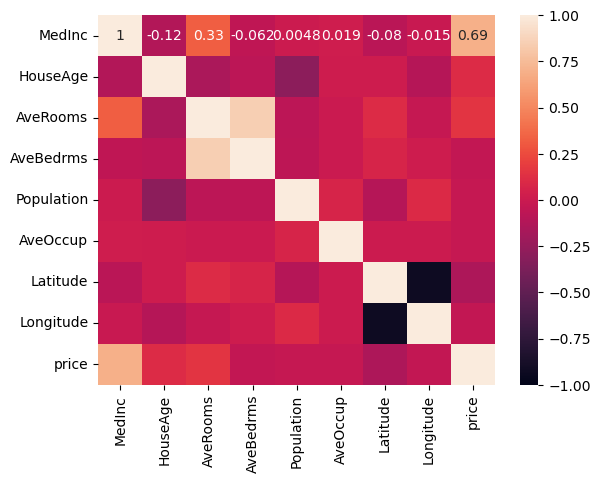

In [22]:

sns.heatmap(df.corr(), annot = True, vmin = -1, vmax = 1)

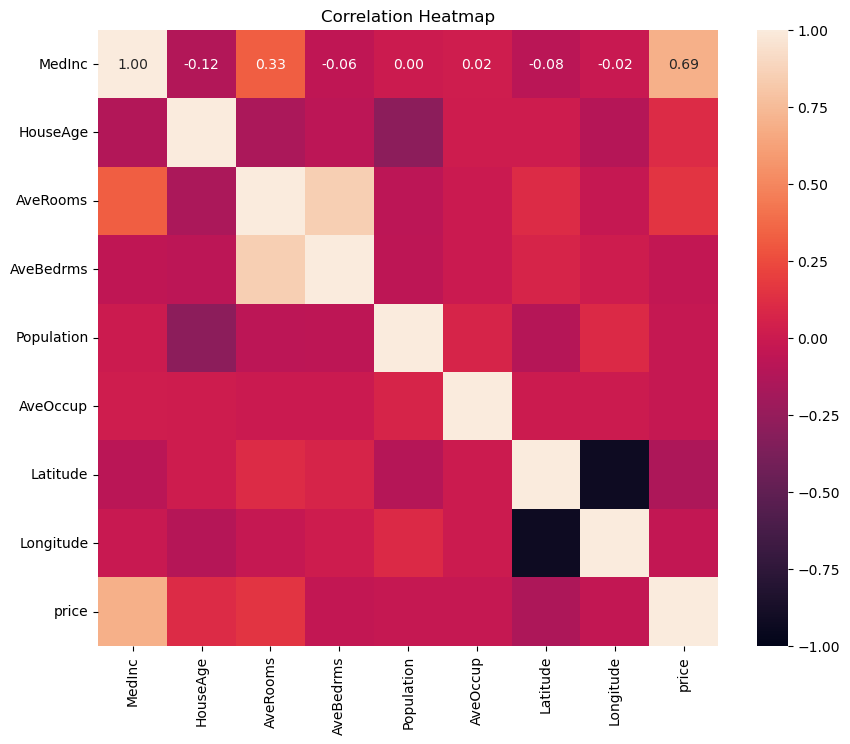

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

### one method is using clustermap but not readable 

<Figure size 500x500 with 0 Axes>

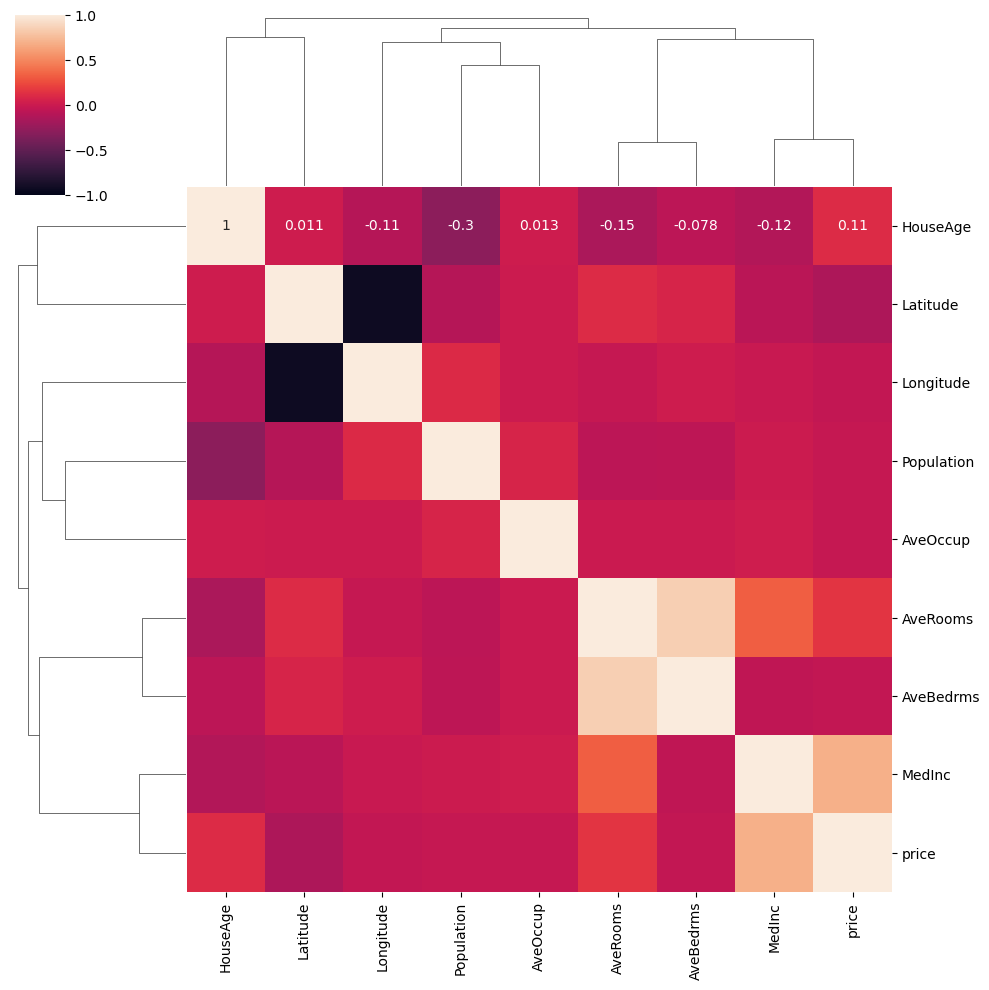

In [ ]:
# cluster map table shows group clusters relationship 
plt.figure(figsize=(5,5))
sns.clustermap(df.corr(), vmin = -1, vmax = 1, annot =  True)

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [28]:
vif = pd.DataFrame()
vif['feature'] = df.columns

In [29]:
vif['VIF'] = [variance_inflation_factor(df.values, i) 
for i in range(len(df.columns)) ]



In [30]:
vif

,feature,VIF
0,MedInc,19.624998
1,HouseAge,7.592663
2,AveRooms,47.956351
3,AveBedrms,45.358192
4,Population,2.936078
5,AveOccup,1.099530
6,Latitude,568.497332
7,Longitude,640.064211
8,price,9.285659


In [ ]:
# if vif > 10 then drop the features one by one >> here highest is longitude, we will drop this and calculate vif and then again drop the highest vif's feature

df1 = df.copy()
df1

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [32]:
df1.drop('Longitude', axis=1, inplace=True)

In [33]:
df1.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,3.521


In [42]:
vif = pd.DataFrame()
vif['feature'] = df1.columns
vif['VIF'] = [variance_inflation_factor(df1.values, i) 
for i in range(len(df1.columns)) ]


In [43]:
vif

,feature,VIF
0,MedInc,8.855104
1,HouseAge,4.156145
2,AveBedrms,4.264253
3,Population,2.223926
4,AveOccup,1.098671
5,price,8.607339


In [ ]:
# now all vif are below 10 we can starts building the model

In [40]:
# df1.drop('AveRooms', axis=1, inplace=True)
df1.drop('Latitude', axis=1, inplace=True)

In [41]:
df1.head(3)

,MedInc,HouseAge,AveBedrms,Population,AveOccup,price
0,8.3252,41.0,1.023810,322.0,2.555556,4.526
1,8.3014,21.0,0.971880,2401.0,2.109842,3.585
2,7.2574,52.0,1.073446,496.0,2.802260,3.521


In [44]:
df1

,MedInc,HouseAge,AveBedrms,Population,AveOccup,price
0,8.3252,41.0,1.023810,322.0,2.555556,4.526
1,8.3014,21.0,0.971880,2401.0,2.109842,3.585
2,7.2574,52.0,1.073446,496.0,2.802260,3.521
3,5.6431,52.0,1.073059,558.0,2.547945,3.413
4,3.8462,52.0,1.081081,565.0,2.181467,3.422
...,...,...,...,...,...,...
20635,1.5603,25.0,1.133333,845.0,2.560606,0.781
20636,2.5568,18.0,1.315789,356.0,3.122807,0.771
20637,1.7000,17.0,1.120092,1007.0,2.325635,0.923
20638,1.8672,18.0,1.171920,741.0,2.123209,0.847


In [48]:
X = df1.iloc[:,:-1] # Independent variables
y = df1.iloc[:, -1] # dep variable

In [49]:
X

,MedInc,HouseAge,AveBedrms,Population,AveOccup
0,8.3252,41.0,1.023810,322.0,2.555556
1,8.3014,21.0,0.971880,2401.0,2.109842
2,7.2574,52.0,1.073446,496.0,2.802260
3,5.6431,52.0,1.073059,558.0,2.547945
4,3.8462,52.0,1.081081,565.0,2.181467
...,...,...,...,...,...
20635,1.5603,25.0,1.133333,845.0,2.560606
20636,2.5568,18.0,1.315789,356.0,3.122807
20637,1.7000,17.0,1.120092,1007.0,2.325635
20638,1.8672,18.0,1.171920,741.0,2.123209


In [50]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: price, Length: 20640, dtype: float64

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=1)

In [52]:
# you can even do scaling but after tarian test split 
# and scaling is optional

In [53]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler

StandardScaler()

In [54]:
# fit transform is for train data
# and transform is for test data 
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
X_train

array([[-0.50715954, -1.07853296,  0.01547783,  1.53466411, -0.03473461],
       [-0.36780162,  0.98848922, -0.08556377,  0.20264384,  0.04136812],
       [-0.72098999,  1.62449604, -0.26582609, -0.12284318, -0.03379571],
       ...,
       [-1.45114921,  1.06799007, -0.18120784, -0.57834812, -0.03858451],
       [-0.65684615, -1.47603722, -0.29089077, -0.09365549, -0.02821367],
       [-0.83089789,  0.5114841 ,  0.15773486, -0.37138083, -0.04325394]])

In [64]:
X_train.shape, X_test.shape

((14448, 5), (6192, 5))

In [56]:
X_test

array([[-0.32961194,  0.82948751, -0.04791601, -0.28293327, -0.10860423],
       [-1.00314873,  0.67048581, -0.11746951, -0.2528611 , -0.0414458 ],
       [ 0.07463726,  1.38599348, -0.17026957,  0.09296887,  0.05285456],
       ...,
       [-0.68105238,  1.46549433, -0.11120214, -0.56154308, -0.02800075],
       [-0.66871091, -1.23753466,  0.01348703,  1.35157766, -0.03129222],
       [-1.14621438,  0.03447898,  0.13277135,  1.77170358, -0.01613065]])

In [57]:
# now build the model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model

LinearRegression()

In [58]:
model.fit(X_train, y_train)

LinearRegression()

In [59]:
model.coef_

array([ 0.8295202 ,  0.23888438,  0.02058888,  0.03902186, -0.05185743])

In [60]:
model.intercept_

2.0765314825581394

In [61]:
y_pred = model.predict(X_test)
y_pred

array([1.99486815, 1.39443153, 2.46691805, ..., 1.83891855, 1.28083607,
       1.20666527])

In [62]:
# performance metrices
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

0.6046846522578226
0.6544937093127862
0.502166171877851


In [63]:
score = r2_score(y_test, y_pred)
score

0.502166171877851

In [65]:
# adjusted r square
num = (1 - score) * (6192 - 1)
den = (6192 - 1 - 5)
score2 = 1 - (num/den)
print("adjusted r2 score is ",score2)

adjusted r2 score is  0.5017637843672447


In [ ]:
y_test.shape, X_test.shape 

((6192,), (6192, 5))

### if i were having 1000 number of features then i was attempting RFE (recursive Feature elimination)

In [67]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [68]:
X = df.iloc[:, :-1] # ind vars
y = df.iloc[:, -1] # dep var

In [69]:
X.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [70]:
from sklearn.feature_selection import RFE

In [93]:
# RFE needs 2 arguements : estimator (linear reg means model ) and how many features u wanna select ?
rfe = RFE(LinearRegression(), n_features_to_select=5) 
# if we add n_feature_to_select as greater than or equal to number of columns in X then it will convert all into true 

In [94]:
rfe

RFE(estimator=LinearRegression(), n_features_to_select=5)

In [95]:
rfe.fit(X,y)

RFE(estimator=LinearRegression(), n_features_to_select=5)

In [96]:
# which are the features has been selected ?
rfe.support_

array([ True, False,  True,  True, False, False,  True,  True])

In [97]:
X.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [99]:
rfe.ranking_ 
# higher ranking == higher priority for predictions

array([1, 2, 1, 1, 4, 3, 1, 1])

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=2)

In [103]:
rfe.predict(X_test) 
# i havent train, test split hence will put X here

array([2.90255712, 1.3336506 , 1.43760563, ..., 1.83111336, 2.40197824,
       2.37811387])